# 01 – Load Data

U ovoj bilježnici učitava se IBM Telco Customer Churn dataset.  
Cilj je upoznati strukturu podataka, pregledati stupce i osnovne statistike prije čišćenja i modeliranja.



## Učitavanje podataka

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

possible_paths = [
    Path("data/Telco_customer_churn.xlsx"),
    Path("../data/Telco_customer_churn.xlsx"),
    Path("/content/drive/MyDrive/csv/Telco_customer_churn.xlsx")
]

DATA_PATH = None
for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Dataset nije pronađen. Provjeri folder data/")

df = pd.read_excel(DATA_PATH)
df.head()



,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Struktura skupa podataka

Dataset sadrži informacije o korisnicima telekomunikacijske usluge, uključujući demografske podatke, korištene usluge, financijske podatke, ugovorne uvjete.
Ciljna varijabla je Churn Label, koja označava je li korisnik napustio uslugu.
U nastavku se analizira broj redaka i stupaca, nazivi varijabli te tipovi podataka.


In [ ]:
df.shape

(7043, 33)

### Opis varijabli

Dataset sadrži ukupno 7043 korisnika i 33 varijable.  
Varijable se mogu grupirati u nekoliko kategorija:

Podaci u skupu mogu se podijeliti u nekoliko skupina:

- **Demografski podaci:** spol (Gender), dobna skupina (Senior Citizen), ima li korisnik partnera (Partner) te uzdržavane osobe (Dependents).  
- **Usluge:** informacije o korištenju telefonskih i internetskih usluga poput tehničke podrške, sigurnosti i streaminga.  
- **Ugovor i naplata:** vrsta ugovora (Contract), način plaćanja (Payment Method) i korištenje bezpapirnog računa (Paperless Billing).  
- **Financijski podaci:** trajanje korisničkog odnosa (Tenure Months), mjesečni trošak (Monthly Charges) i ukupni trošak (Total Charges).  
- **Ciljna varijabla:** *Churn Label*, koja označava je li korisnik napustio uslugu.


Lokacijski podaci (država, grad i geografske koordinate) ne smatraju se izravno relevantnima za predikciju churn-a te bi njihovo uključivanje moglo nepotrebno povećati složenost modela bez značajnog poboljšanja rezultata.


In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Opisna statistika

U nastavku je prikazana osnovna opisna statistika numeričkih varijabli.  
Ona daje uvid u raspon vrijednosti, srednje vrijednosti te distribuciju podataka.


In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


Iz statistike je vidljivo da korisnici u prosjeku ostaju oko 32 mjeseca kod operatera, dok je prosječni mjesečni trošak oko 65 jedinica.  
Postoji značajna varijabilnost u duljini korištenja usluge, što može biti važan faktor u predikciji churn-a.


## Analiza ciljne varijable (Churn)

Ciljna varijabla *Churn Label* označava je li korisnik napustio uslugu (Yes) ili je i dalje aktivan (No).  
Analizira se raspodjela kako bi se utvrdilo postoji li neuravnoteženost klasa.


In [ ]:
df["Churn Label"].value_counts()


,count
Churn Label,
No,5174
Yes,1869


In [ ]:
df["Churn Label"].value_counts(normalize=True)


,proportion
Churn Label,
No,0.73463
Yes,0.26537


Za analizu ciljne varijable korištene su apsolutne i relativne frekvencije.
Apsolutne vrijednosti prikazuju stvaran broj korisnika u svakoj klasi, dok relativne vrijednosti (normalizirane) omogućuju uvid u postotnu raspodjelu klasa i procjenu neuravnoteženosti podataka. Rezultati pokazuju da je oko 26.5% korisnika napustilo uslugu, dok je oko 73.5% ostalo.  
To znači da dataset ima umjerenu neuravnoteženost klasa, što će se uzeti u obzir prilikom izrade modela strojnog učenja.


##Gafički prikaz

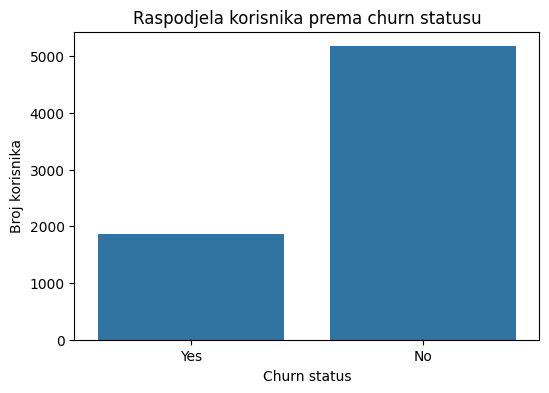

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x="Churn Label", data=df)
plt.title("Raspodjela korisnika prema churn statusu")
plt.xlabel("Churn status")
plt.ylabel("Broj korisnika")
plt.show()